# Smartphone Addiction — EDA

## Understand the Dataset

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [37]:
df.shape

(7500, 16)

In [38]:
df.dtypes

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

In [39]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [40]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [41]:
# categorical columns summary

cat_cols = ['gender', 'stress_level', 'addiction_level']
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print()

gender
gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

stress_level
stress_level
High      2560
Low       2503
Medium    2437
Name: count, dtype: int64

addiction_level
addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64



In [42]:
df['addicted_label'].value_counts()

addicted_label
1    5308
0    2192
Name: count, dtype: int64

In [43]:
# target variable overview

print('Addicted users :', df['addicted_label'].sum())
print('Not addicted   :', (df['addicted_label']==0).sum())
print('addicted   :', (df['addicted_label']==1).sum())

print('Addiction rate :', round(df['addicted_label'].mean()*100, 1), '%')

Addicted users : 5308
Not addicted   : 2192
addicted   : 5308
Addiction rate : 70.8 %


## 1. Univariate Analysis
-  Look at each feature individually — distributions, counts, spread.

### 1a. Numerical Features

In [44]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [45]:
num_cols

Index(['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time', 'addicted_label'],
      dtype='object')

In [46]:
cat_cols

Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level'],
      dtype='object')

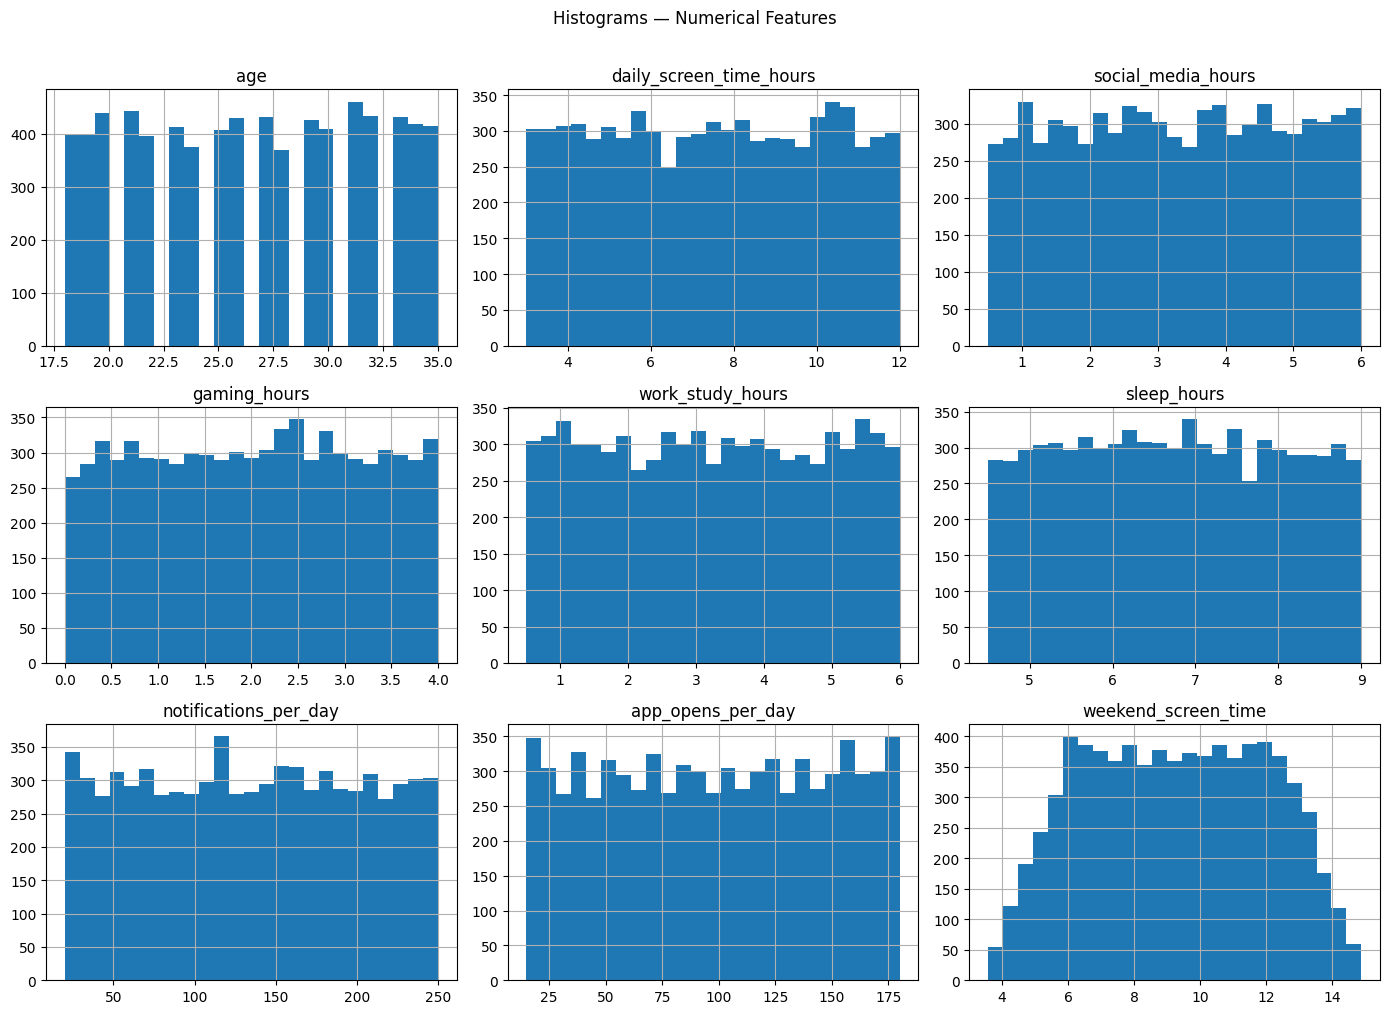

In [47]:
num_cols = ['age','daily_screen_time_hours','social_media_hours','gaming_hours',
            'work_study_hours','sleep_hours','notifications_per_day',
            'app_opens_per_day','weekend_screen_time']

df[num_cols].hist(bins=25, figsize=(14,10))
plt.suptitle('Histograms — Numerical Features', y=1.01)
plt.tight_layout()
plt.show()

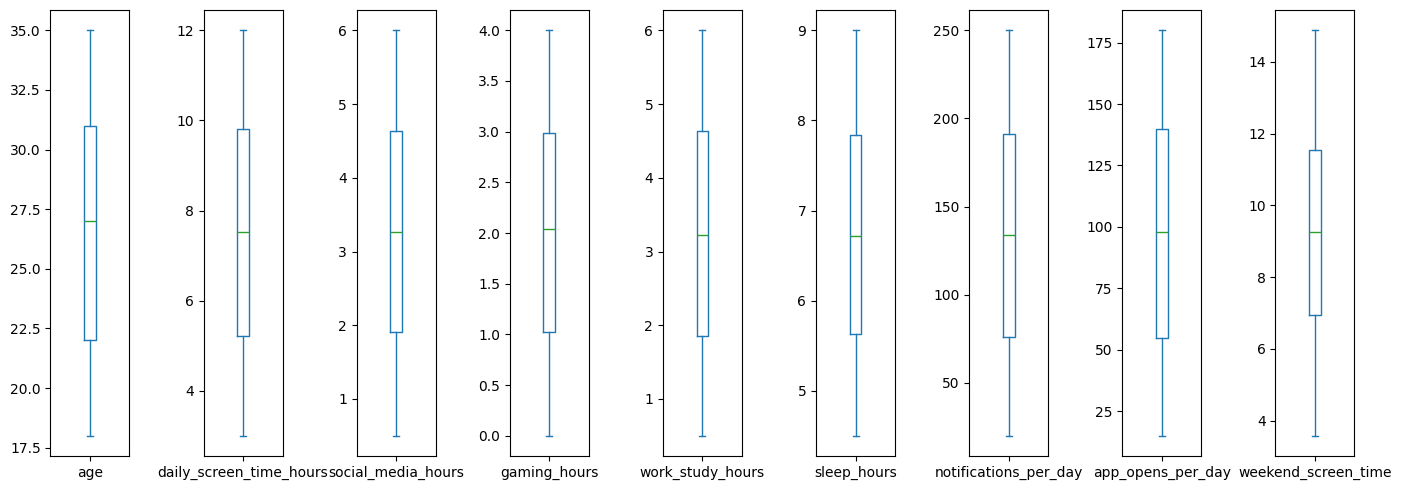

In [67]:
# boxplots to spot outliers
df[num_cols].plot(kind='box', figsize=(14, 5), subplots=True)
plt.tight_layout()
plt.show()

In [49]:
# basic stats per column
df[num_cols].agg(['mean','median','std','min','max']).round(2)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
mean,26.57,7.50,3.27,2.01,3.24,6.74,134.26,97.83,9.24
median,27.00,7.52,3.27,2.04,3.23,6.72,134.00,98.00,9.26
std,5.20,2.61,1.59,1.15,1.60,1.28,66.59,48.42,2.72
min,18.00,3.00,0.50,0.00,0.50,4.50,20.00,15.00,3.58
max,35.00,12.00,6.00,4.00,6.00,9.00,250.00,180.00,14.88


### 1b. Categorical Features

In [50]:
cat_cols

Index(['transaction_id', 'user_id', 'gender', 'stress_level',
       'academic_work_impact', 'addiction_level'],
      dtype='object')

In [51]:
cat_cols = ['gender', 'stress_level', 'addiction_level','academic_work_impact']


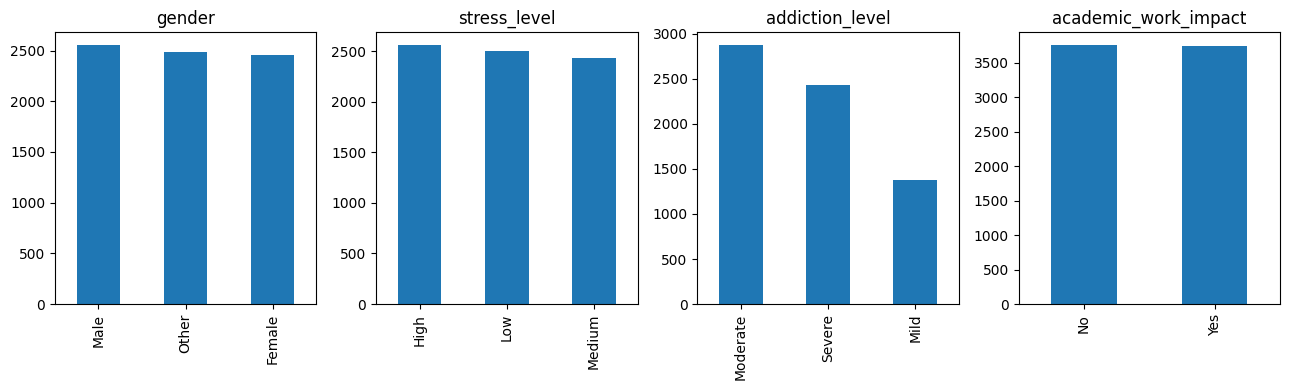

In [52]:

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### 1c. Target Variable

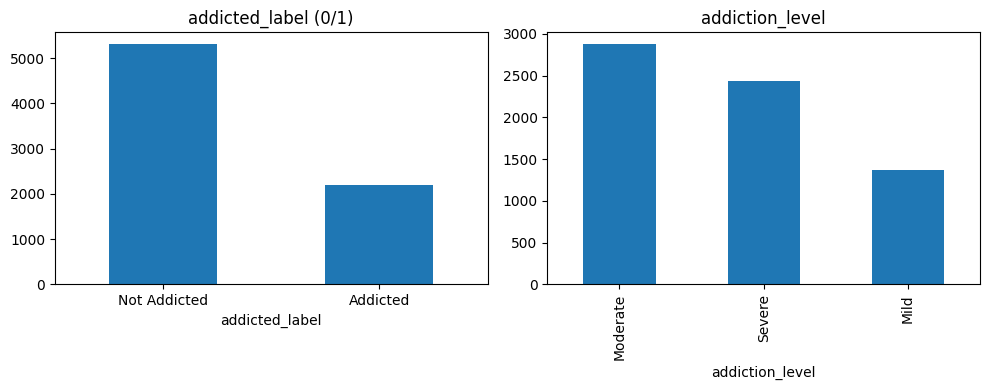

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['addicted_label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('addicted_label (0/1)')
axes[0].set_xticklabels(['Not Addicted','Addicted'], rotation=0)

df['addiction_level'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('addiction_level')

plt.tight_layout()
plt.show()

---
## 2. Bivariate Analysis
> How does each feature relate to the **target** (`addicted_label`)?

### 2a. Numerical Features vs Target

In [54]:
# mean of each numeric feature grouped by addiction
df.groupby('addicted_label')[num_cols].mean().round(2)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
addicted_label,,,,,,,,,
0,26.53,5.16,2.25,2.00,3.24,6.67,134.33,97.00,6.89
1,26.58,8.47,3.70,2.02,3.24,6.77,134.23,98.18,10.21


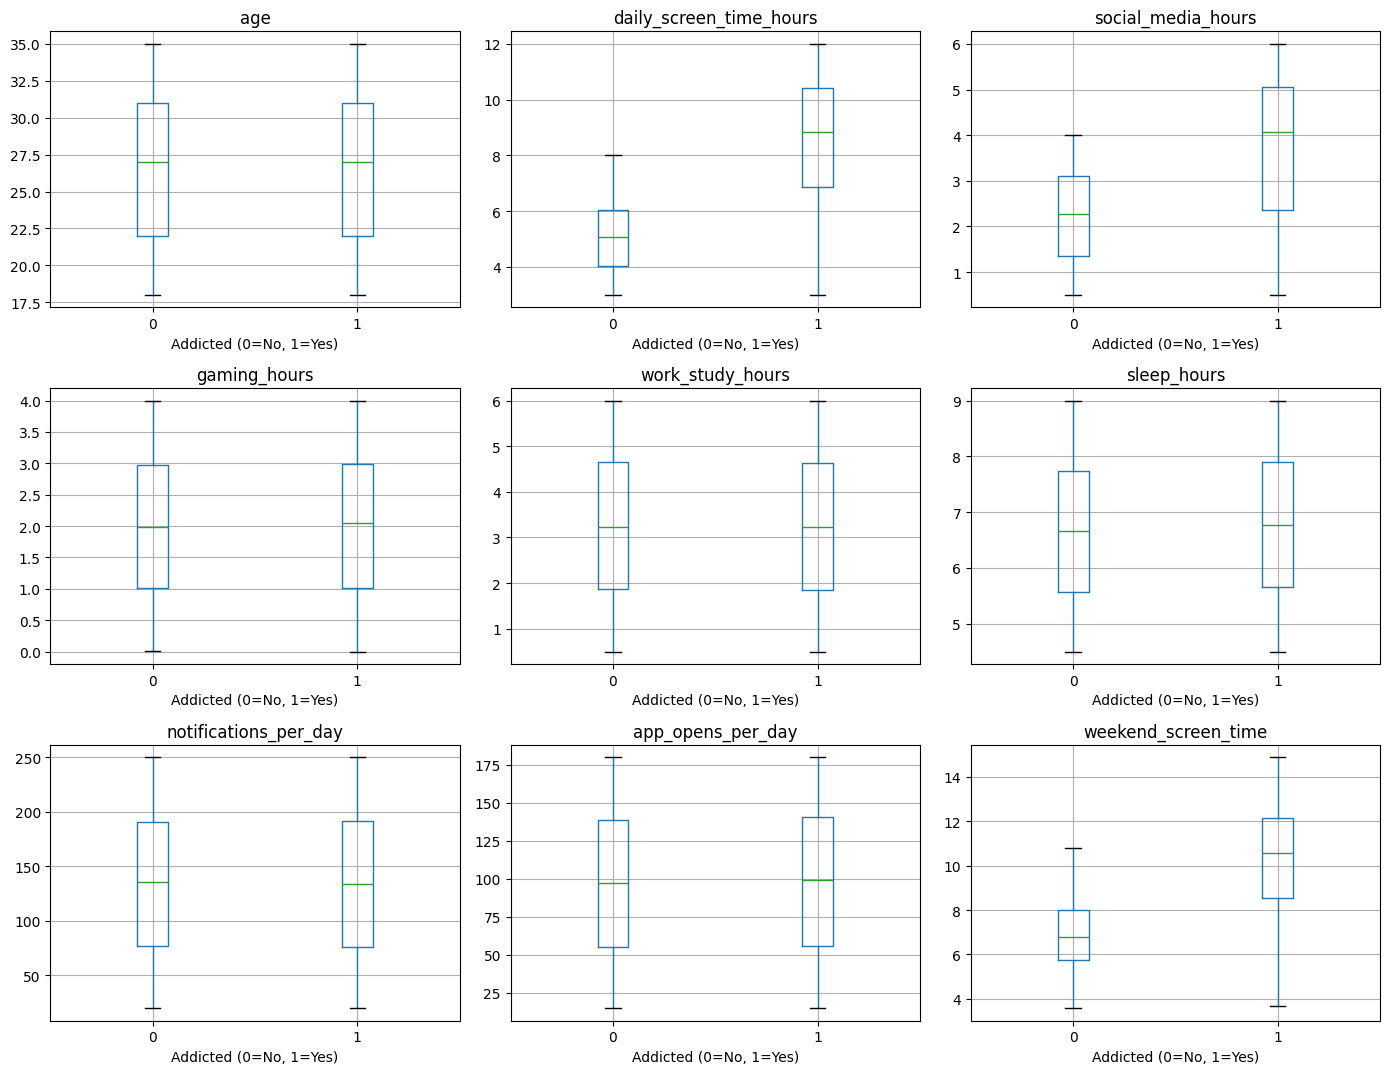

In [68]:
# boxplot: each numeric feature split by addicted_label
fig, axes = plt.subplots(3,3, figsize=(14, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='addicted_label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Addicted (0=No, 1=Yes)')

plt.suptitle('')
plt.tight_layout()
plt.show()

### 2b. Categorical Features vs Target

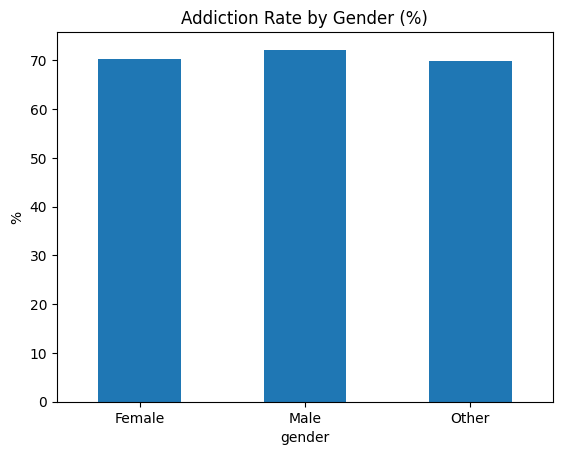

In [56]:
# addiction rate by gender
df.groupby('gender')['addicted_label'].mean().mul(100).round(1).plot(kind='bar')
plt.title('Addiction Rate by Gender (%)')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.show()

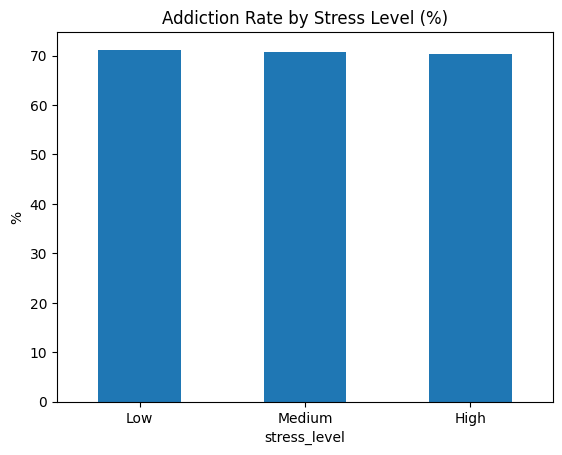

In [57]:
# addiction rate by stress level
order = ['Low','Medium','High']
df.groupby('stress_level')['addicted_label'].mean().reindex(order).mul(100).round(1).plot(kind='bar')
plt.title('Addiction Rate by Stress Level (%)')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.show()

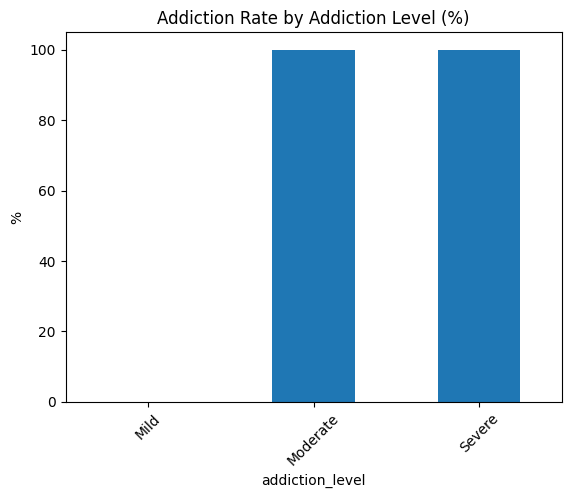

In [58]:
# addiction rate by addiction_level
df.groupby('addiction_level')['addicted_label'].mean().mul(100).round(1).plot(kind='bar')
plt.title('Addiction Rate by Addiction Level (%)')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.show()

### 2c. Numerical Feature Pairs (scatter)

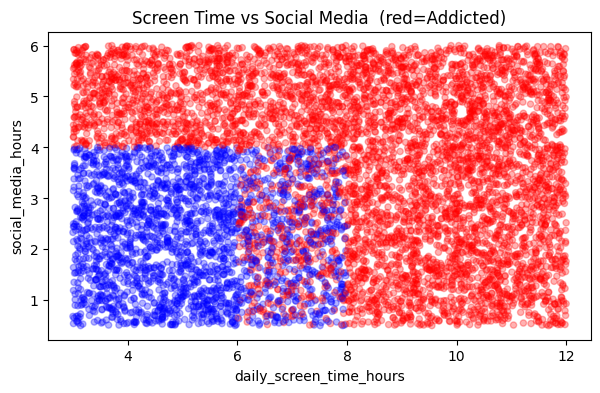

In [59]:
# screen time vs social media — coloured by addiction
colors = df['addicted_label'].map({0:'blue', 1:'red'})
df.plot.scatter(x='daily_screen_time_hours', y='social_media_hours', c=colors, alpha=0.3, figsize=(7,4))
plt.title('Screen Time vs Social Media  (red=Addicted)')
plt.show()

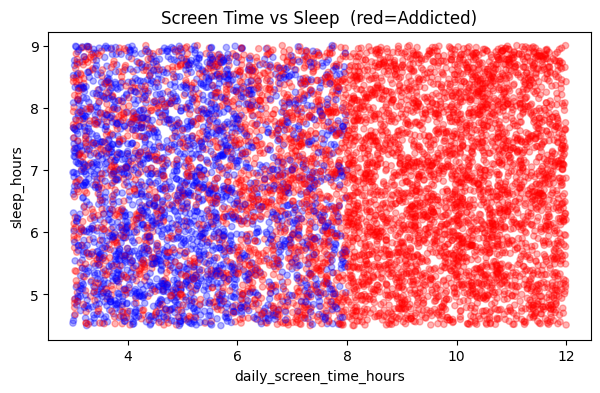

In [60]:
# screen time vs sleep hours
df.plot.scatter(x='daily_screen_time_hours', y='sleep_hours', c=colors, alpha=0.3, figsize=(7,4))
plt.title('Screen Time vs Sleep  (red=Addicted)')
plt.show()

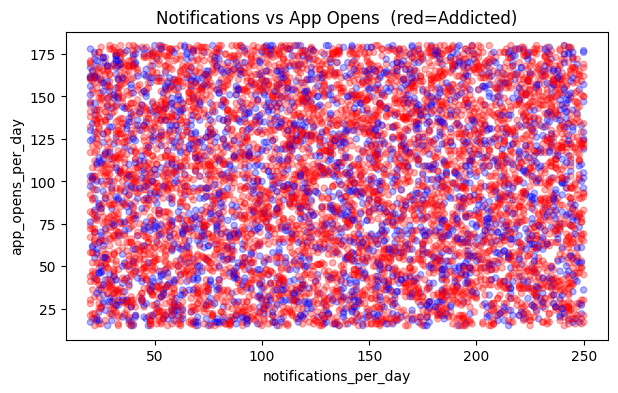

In [61]:
# notifications vs app opens
df.plot.scatter(x='notifications_per_day', y='app_opens_per_day', c=colors, alpha=0.3, figsize=(7,4))
plt.title('Notifications vs App Opens  (red=Addicted)')
plt.show()

---
## 3. Multivariate Analysis
> How do multiple features interact together?

### 3a. Correlation Matrix

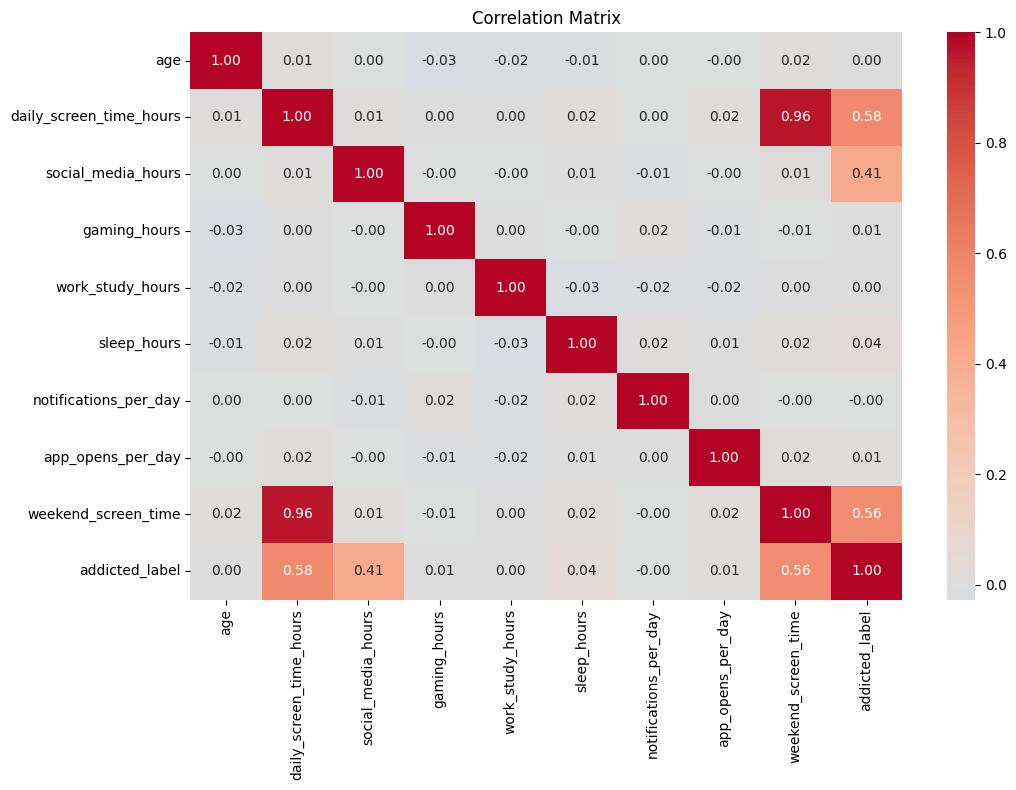

In [62]:
import seaborn as sns

corr = df[num_cols + ['addicted_label']].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 3b. Addiction rate — Stress × Gender

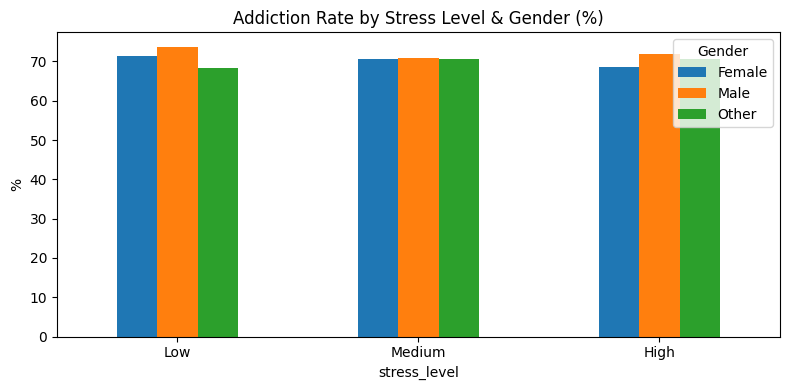

In [63]:
pivot = df.groupby(['stress_level','gender'])['addicted_label'].mean().mul(100).round(1).unstack()
pivot = pivot.reindex(['Low','Medium','High'])

pivot.plot(kind='bar', figsize=(8,4))
plt.title('Addiction Rate by Stress Level & Gender (%)')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### 3c. Avg Screen Time — Age Group × Stress

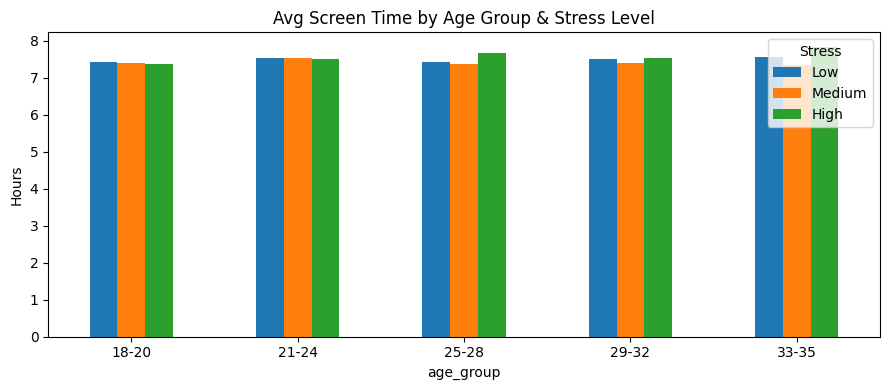

In [64]:
df['age_group'] = pd.cut(df['age'], bins=[17,20,24,28,32,36],
                          labels=['18-20','21-24','25-28','29-32','33-35'])

pivot2 = df.groupby(['age_group','stress_level'], observed=True)['daily_screen_time_hours'].mean().round(2).unstack()
pivot2 = pivot2[['Low','Medium','High']]

pivot2.plot(kind='bar', figsize=(9,4))
plt.title('Avg Screen Time by Age Group & Stress Level')
plt.ylabel('Hours')
plt.xticks(rotation=0)
plt.legend(title='Stress')
plt.tight_layout()
plt.show()

### 3d. Pair Plot (key features)

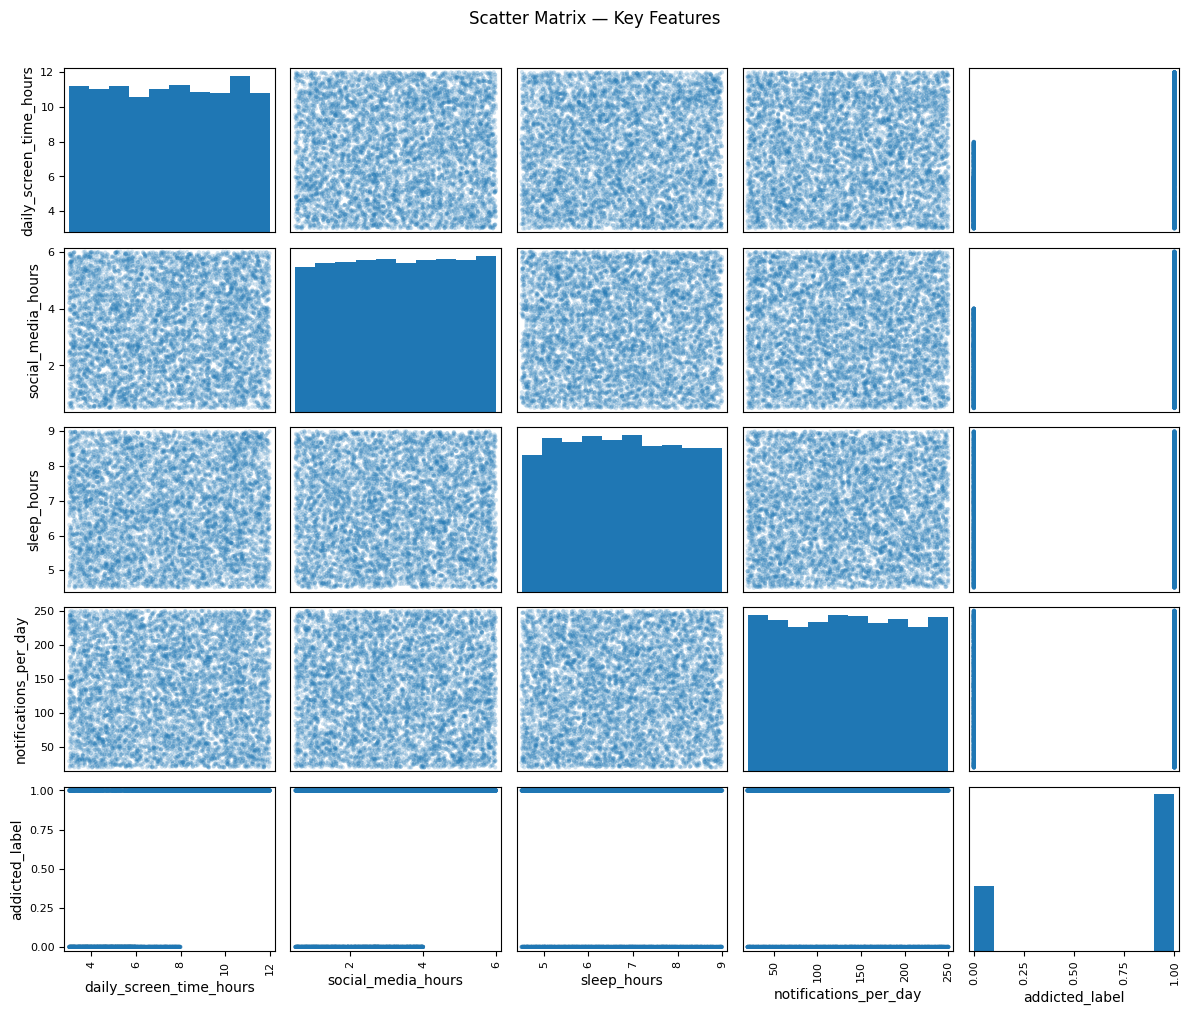

In [65]:
key = ['daily_screen_time_hours','social_media_hours','sleep_hours',
       'notifications_per_day','addicted_label']

pd.plotting.scatter_matrix(df[key], figsize=(12,10), alpha=0.2, diagonal='hist')
plt.suptitle('Scatter Matrix — Key Features', y=1.01)
plt.tight_layout()
plt.show()

### 3e. Feature Importance

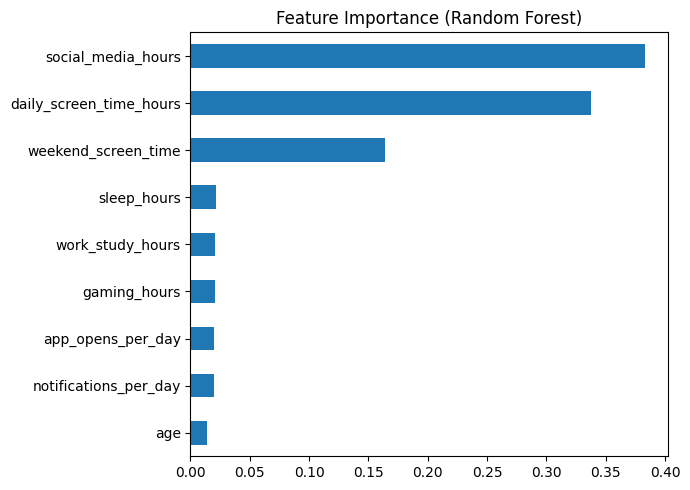

In [66]:
from sklearn.ensemble import RandomForestClassifier

X = df[num_cols]
y = df['addicted_label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', figsize=(7,5))
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

---
## Summary

| Section | Key Finding |
|---------|------------|
| **Univariate** | Screen time & social media are right-skewed; sleep is normally distributed |
| **Bivariate** | Addicted users show higher screen time, more notifications, less sleep |
| **Bivariate** | High stress → highest addiction rate; gender has little impact |
| **Multivariate** | Screen time + social media + stress together are the strongest indicators |
| **Multivariate** | Sleep hours negatively correlate with addiction |